# Atividade de series temporais

Essa atividade é para um fim didático de estudar series temporais por completo, classifica-las e aprofundar o conhecimento

## Carregando a base

#### Base que guarda o preço de casas vendidas no periodo de 2007-2019

In [2]:
!pip install kagglehub

import kagglehub

path_sales = kagglehub.dataset_download("htagholdings/property-sales")

print("Path to dataset files:", path_sales)

Path to dataset files: C:\Users\miguelaraujo-ieg\.cache\kagglehub\datasets\htagholdings\property-sales\versions\3


#### Base que guarda o consumo de energia de casas no periodo de 2006 a 2010

In [3]:
path_eletricpower = kagglehub.dataset_download("uciml/electric-power-consumption-data-set")

print("Path to dataset files:", path_eletricpower)

Path to dataset files: C:\Users\miguelaraujo-ieg\.cache\kagglehub\datasets\uciml\electric-power-consumption-data-set\versions\1


#### Base que guarda as vendas da amazon do fim de 2021 a 2023

In [4]:
path_amazon = kagglehub.dataset_download("aliiihussain/amazon-sales-dataset")
print("Path to dataset files:", path_amazon)

100%|██████████| 1.24M/1.24M [00:01<00:00, 1.23MB/s]

Extracting files...
Path to dataset files: C:\Users\miguelaraujo-ieg\.cache\kagglehub\datasets\aliiihussain\amazon-sales-dataset\versions\1


#### Base que guarda os dados dos jogos do brasil de 1914 a 2023

In [5]:

path_brazil = kagglehub.dataset_download("azminetoushikwasi/brazil-all-international-matches-19142023")

print("Path to dataset files:", path_brazil)

100%|██████████| 9.33k/9.33k [00:00<00:00, 2.34MB/s]

Extracting files...
Path to dataset files: C:\Users\miguelaraujo-ieg\.cache\kagglehub\datasets\azminetoushikwasi\brazil-all-international-matches-19142023\versions\4


In [6]:
import pandas as pd
import os
df_property_sales = pd.read_csv(os.path.join(path_sales, "raw_sales.csv"))
df_electric_power = pd.read_csv(os.path.join(path_eletricpower, "household_power_consumption.txt"), sep=";")
df_amazon = pd.read_csv(os.path.join(path_amazon, "amazon_sales_dataset.csv"))
df_brazil = pd.read_csv(os.path.join(path_brazil, "brazil.csv"))

C:\Users\miguelaraujo-ieg\AppData\Local\Temp\ipykernel_5008\3669513611.py:4: DtypeWarning: Columns (0: Global_active_power, 1: Global_reactive_power, 2: Voltage, 3: Global_intensity, 4: Sub_metering_1, 5: Sub_metering_2) have mixed types. Specify dtype option on import or set low_memory=False.
  df_electric_power = pd.read_csv(os.path.join(path_eletricpower, "household_power_consumption.txt"), sep=";")


### Retirando NAN

In [7]:
df_amazon = df_amazon.dropna(subset=['order_date', 'total_revenue'])
df_electric_power = df_electric_power.dropna(subset=['Date', 'Time', 'Global_active_power'])
df_property_sales = df_property_sales.dropna(subset=['datesold', 'price'])
df_brazil = df_brazil.dropna(subset=['Date', 'Result'])

## Transformando em series temporais - Tratamento da base, Granularidade, Limpeza e Entendimento

### Metodo para normalizar a serie caso seja necessário

In [8]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np

def normalizar_serie(serie, metodo):
    """
    metodo: 'minmax' (0 a 1) ou 'zscore' (média 0, desvio 1)
    """
    valores = serie.values.reshape(-1, 1)
    
    if metodo == 'minmax':
        scaler = MinMaxScaler()
        norm = scaler.fit_transform(valores).flatten()
    elif metodo == 'zscore':
        norm = (valores.flatten() - valores.mean()) / valores.std()
    else:
        raise ValueError("Use 'minmax' ou 'zscore'")
    
    return pd.Series(norm, index=serie.index, name=serie.name)


### Serie de venda de casas

In [9]:
serie_property_sales = df_property_sales[["price","datesold"]]

In [10]:

serie_property_sales['datesold'] = pd.to_datetime(
    serie_property_sales['datesold'],
    errors='coerce'
)

serie_property_sales = serie_property_sales.dropna(subset=['datesold'])

serie_property_sales = serie_property_sales.set_index('datesold')

serie_property_sales = serie_property_sales.sort_index()

serie_property_sales = serie_property_sales.resample('MS').mean()

In [11]:
serie_property_sales

,price
datesold,
2007-02-01,407500.000000
2007-03-01,339333.333333
2007-04-01,798000.000000
2007-05-01,339500.000000
2007-06-01,520333.333333
...,...
2019-03-01,651666.737288
2019-04-01,655325.561321
2019-05-01,641491.136364


### Serie de energia eletrica

In [12]:
df_electric_power

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.840,18.400,0.000,1.000,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.630,23.000,0.000,1.000,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.290,23.000,0.000,2.000,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.740,23.000,0.000,1.000,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.680,15.800,0.000,1.000,17.0
...,...,...,...,...,...,...,...,...,...
2075254,26/11/2010,20:58:00,0.946,0.0,240.43,4.0,0.0,0.0,0.0
2075255,26/11/2010,20:59:00,0.944,0.0,240.0,4.0,0.0,0.0,0.0
2075256,26/11/2010,21:00:00,0.938,0.0,239.82,3.8,0.0,0.0,0.0
2075257,26/11/2010,21:01:00,0.934,0.0,239.7,3.8,0.0,0.0,0.0


In [13]:
df_electric_power['datetime'] = pd.to_datetime(
    df_electric_power['Date'] + ' ' + df_electric_power['Time'],
    format='%d/%m/%Y %H:%M:%S'
)

df_electric_power = df_electric_power.set_index('datetime')
df_electric_power

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
datetime,,,,,,,,,
2006-12-16 17:24:00,16/12/2006,17:24:00,4.216,0.418,234.840,18.400,0.000,1.000,17.0
2006-12-16 17:25:00,16/12/2006,17:25:00,5.360,0.436,233.630,23.000,0.000,1.000,16.0
2006-12-16 17:26:00,16/12/2006,17:26:00,5.374,0.498,233.290,23.000,0.000,2.000,17.0
2006-12-16 17:27:00,16/12/2006,17:27:00,5.388,0.502,233.740,23.000,0.000,1.000,17.0
2006-12-16 17:28:00,16/12/2006,17:28:00,3.666,0.528,235.680,15.800,0.000,1.000,17.0
...,...,...,...,...,...,...,...,...,...
2010-11-26 20:58:00,26/11/2010,20:58:00,0.946,0.0,240.43,4.0,0.0,0.0,0.0
2010-11-26 20:59:00,26/11/2010,20:59:00,0.944,0.0,240.0,4.0,0.0,0.0,0.0
2010-11-26 21:00:00,26/11/2010,21:00:00,0.938,0.0,239.82,3.8,0.0,0.0,0.0


In [14]:
serie_electric_power = df_electric_power['Global_active_power']
serie_electric_power

datetime
2006-12-16 17:24:00    4.216
2006-12-16 17:25:00    5.360
2006-12-16 17:26:00    5.374
2006-12-16 17:27:00    5.388
2006-12-16 17:28:00    3.666
                       ...  
2010-11-26 20:58:00    0.946
2010-11-26 20:59:00    0.944
2010-11-26 21:00:00    0.938
2010-11-26 21:01:00    0.934
2010-11-26 21:02:00    0.932
Name: Global_active_power, Length: 2075259, dtype: object

In [15]:
serie_electric_power = pd.Series(serie_electric_power)
serie_electric_power = pd.to_numeric(serie_electric_power, errors='coerce')
serie_electric_power = serie_electric_power.dropna()
serie_electric_power = serie_electric_power.resample('MS').mean()
serie_electric_power

datetime
2006-12-01    1.901295
2007-01-01    1.546034
2007-02-01    1.401084
2007-03-01    1.318627
2007-04-01    0.891189
2007-05-01    0.985862
2007-06-01    0.826814
2007-07-01    0.667367
2007-08-01    0.764186
2007-09-01    0.969318
2007-10-01    1.103911
2007-11-01    1.294473
2007-12-01    1.626474
2008-01-01    1.459920
2008-02-01    1.181384
2008-03-01    1.245337
2008-04-01    1.115972
2008-05-01    1.024281
2008-06-01    0.994096
2008-07-01    0.794781
2008-08-01    0.276488
2008-09-01    0.987680
2008-10-01    1.136768
2008-11-01    1.387066
2008-12-01    1.275189
2009-01-01    1.410202
2009-02-01    1.247568
2009-03-01    1.226735
2009-04-01    1.140690
2009-05-01    1.012856
2009-06-01    0.840756
2009-07-01    0.618121
2009-08-01    0.664619
2009-09-01    0.986841
2009-10-01    1.144486
2009-11-01    1.274743
2009-12-01    1.364421
2010-01-01    1.430525
2010-02-01    1.375855
2010-03-01    1.130075
2010-04-01    1.027295
2010-05-01    1.095284
2010-06-01    0.969615
20

In [16]:
serie_property_sales = pd.Series(serie_property_sales['price'])
serie_property_sales

datesold
2007-02-01    407500.000000
2007-03-01    339333.333333
2007-04-01    798000.000000
2007-05-01    339500.000000
2007-06-01    520333.333333
                  ...      
2019-03-01    651666.737288
2019-04-01    655325.561321
2019-05-01    641491.136364
2019-06-01    703275.396825
2019-07-01    583192.056000
Freq: MS, Name: price, Length: 150, dtype: float64

### Serie da amazon

In [17]:
df_amazon

,order_id,order_date,product_id,product_category,price,discount_percent,quantity_sold,customer_region,payment_method,rating,review_count,discounted_price,total_revenue
0,1,2022-04-13,2637,Books,128.75,10,4,North America,UPI,3.5,443,115.88,463.52
1,2,2023-03-12,2300,Fashion,302.60,20,5,Asia,Credit Card,3.7,475,242.08,1210.40
2,3,2022-09-28,3670,Sports,495.80,20,2,Europe,UPI,4.4,183,396.64,793.28
3,4,2022-04-17,2522,Books,371.95,15,4,Middle East,UPI,5.0,212,316.16,1264.64
4,5,2022-03-13,1717,Beauty,201.68,0,4,Middle East,UPI,4.6,308,201.68,806.72
...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,49996,2022-09-03,1433,Beauty,26.99,0,5,Middle East,Credit Card,2.4,386,26.99,134.95
49996,49997,2022-07-03,1428,Beauty,294.23,10,5,Asia,Credit Card,3.1,8,264.81,1324.05
49997,49998,2023-02-17,4651,Electronics,352.11,30,4,Asia,Debit Card,3.1,104,246.48,985.92
49998,49999,2022-09-30,4371,Beauty,307.54,5,1,Middle East,UPI,1.8,316,292.16,292.16


In [18]:
df_amazon['order_date'] = pd.to_datetime(df_amazon['order_date'], errors='coerce')
df_amazon = df_amazon.dropna(subset=['order_date'])
df_amazon['total_revenue'] = pd.to_numeric(df_amazon['total_revenue'], errors='coerce')
df_amazon = df_amazon.set_index('order_date').sort_index()

serie_amazon = df_amazon['total_revenue'].resample('MS').sum().dropna()

serie_amazon

order_date
2022-01-01    1419751.89
2022-02-01    1266714.29
2022-03-01    1392585.42
2022-04-01    1371955.83
2022-05-01    1374779.57
2022-06-01    1352125.49
2022-07-01    1346089.18
2022-08-01    1449308.06
2022-09-01    1403967.06
2022-10-01    1334818.11
2022-11-01    1291100.05
2022-12-01    1386209.61
2023-01-01    1464174.99
2023-02-01    1238380.51
2023-03-01    1366418.41
2023-04-01    1307017.94
2023-05-01    1431398.77
2023-06-01    1394822.13
2023-07-01    1442176.66
2023-08-01    1396321.88
2023-09-01    1341007.86
2023-10-01    1425936.23
2023-11-01    1334328.47
2023-12-01    1335185.33
Freq: MS, Name: total_revenue, dtype: float64

### Serie dos jogos do Brasil

In [19]:
df_brazil

,Date,Match,Result,Score,Competition
0,20 Sep 1914,Argentina v Brazil,L,3-0,International Friendly
1,27 Sep 1914,Argentina v Brazil,W,0-1,Copa Julio Roca
2,08 Jul 1916,Chile v Brazil,D,1-1,Copa America
3,10 Jul 1916,Argentina v Brazil,D,1-1,Copa America
4,12 Jul 1916,Uruguay v Brazil,L,2-1,Copa America
...,...,...,...,...,...
1029,24 Nov 2022,Brazil v Serbia,W,2-0,FIFA World Cup
1030,28 Nov 2022,Brazil v Switzerland,W,1-0,FIFA World Cup
1031,02 Dec 2022,Cameroon v Brazil,L,1-0,FIFA World Cup
1032,05 Dec 2022,Brazil v Korea Republic,W,4-1,FIFA World Cup


In [20]:
df_brazil = df_brazil[['Date', 'Result']]
df_brazil

,Date,Result
0,20 Sep 1914,L
1,27 Sep 1914,W
2,08 Jul 1916,D
3,10 Jul 1916,D
4,12 Jul 1916,L
...,...,...
1029,24 Nov 2022,W
1030,28 Nov 2022,W
1031,02 Dec 2022,L
1032,05 Dec 2022,W


### Vou fazer uma conversão disso em uma base que conta as vitórias que o Brasil teve, agrupando pelo ano para conseguir transformar isso em uma serie temporal

In [21]:
df_brazil['Date'] = pd.to_datetime(df_brazil['Date'], format='%d %b %Y')
df_brazil

,Date,Result
0,1914-09-20,L
1,1914-09-27,W
2,1916-07-08,D
3,1916-07-10,D
4,1916-07-12,L
...,...,...
1029,2022-11-24,W
1030,2022-11-28,W
1031,2022-12-02,L
1032,2022-12-05,W


In [22]:
# 2. Criar coluna numérica (W = 1, L = 0)
df_brazil['win'] = (df_brazil['Result'] == 'W').astype(int)

# 3. Extrair o ano
df_brazil['year'] = df_brazil['Date'].dt.year

# 4. Agrupar e somar
serie_brazil = df_brazil.groupby('year')['win'].sum()
serie_brazil

year
1914     1
1916     2
1917     1
1919     3
1920     1
        ..
2018    13
2019     9
2020     4
2021    12
2022    10
Name: win, Length: 97, dtype: int64

### Normalizando as series

In [23]:
serie_amazon = normalizar_serie(serie_amazon, 'minmax')
serie_electric_power = normalizar_serie(serie_electric_power, 'minmax')
serie_property_sales = normalizar_serie(serie_property_sales, 'zscore')
serie_brazil = normalizar_serie(serie_brazil, 'minmax')

## Estruturando as estacionariedade ou não das series

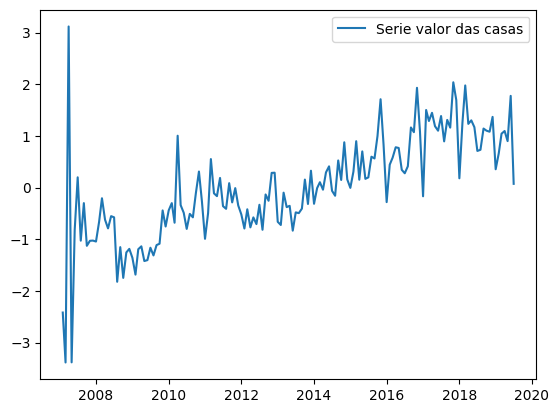

In [24]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()
ax.plot(serie_property_sales, label='Serie valor das casas')
ax.legend()
plt.show()

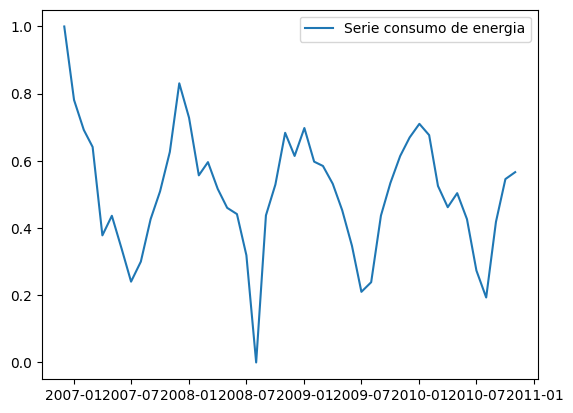

In [25]:
fig, ax = plt.subplots()
ax.plot(serie_electric_power, label='Serie consumo de energia')
ax.legend()
plt.show()

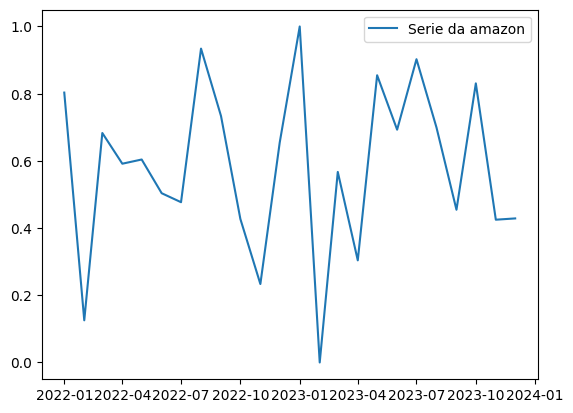

In [26]:
fig, ax = plt.subplots()
ax.plot(serie_amazon, label='Serie da amazon')
ax.legend()
plt.show()

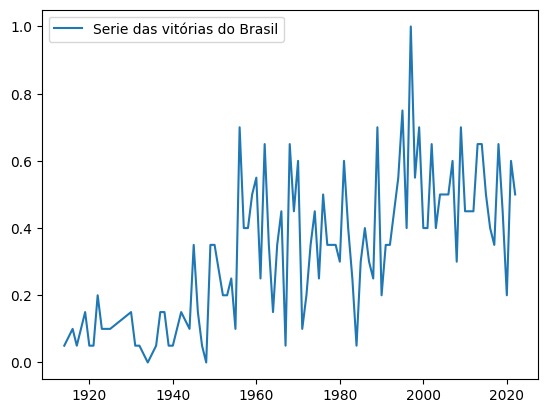

In [27]:
fig, ax = plt.subplots()
ax.plot(serie_brazil, label='Serie das vitórias do Brasil')
ax.legend()
plt.show()


### Plotando grafico acf (autorrelation) para verficar a estacionariedade das series

#### valor das propriedades

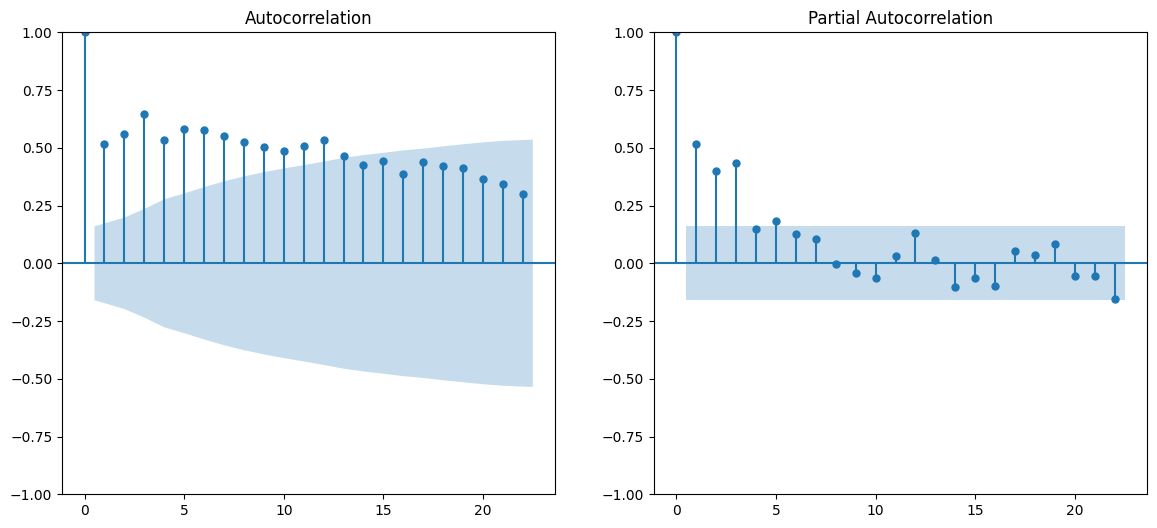

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

plot_acf(serie_property_sales, ax=axes[0])
plot_pacf(serie_property_sales, ax=axes[1])
plt.show()

#### consumo de energia

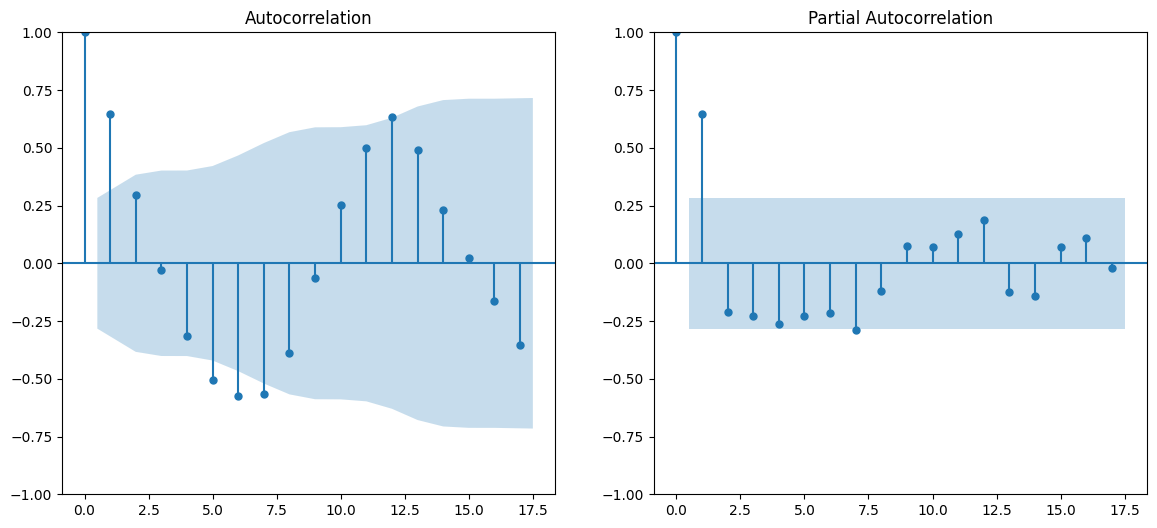

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

plot_acf(serie_electric_power, ax=axes[0])
plot_pacf(serie_electric_power, ax=axes[1])
plt.show()

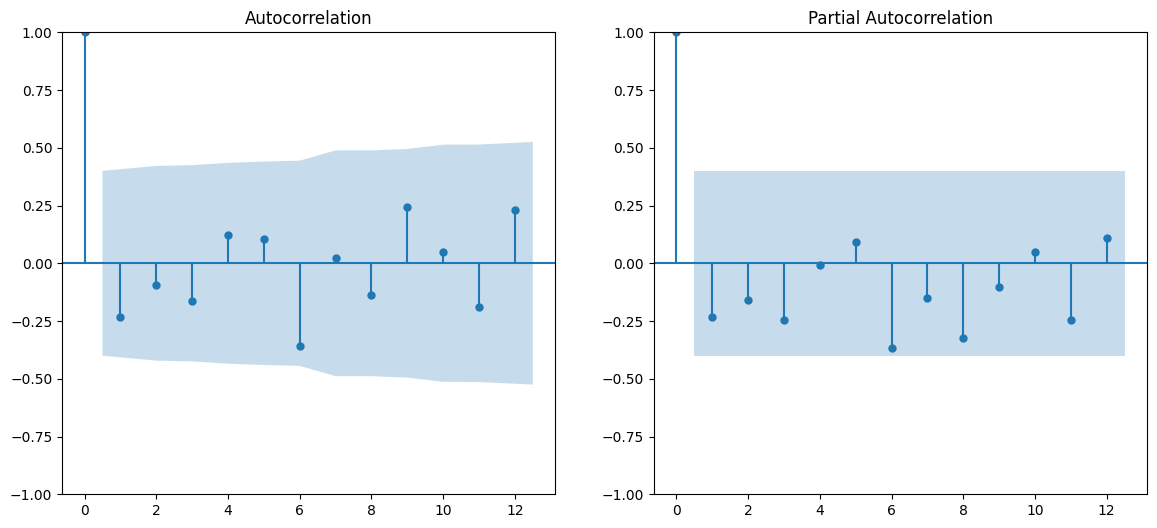

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

plot_acf(serie_amazon, ax=axes[0])
plot_pacf(serie_amazon, ax=axes[1])
plt.show()

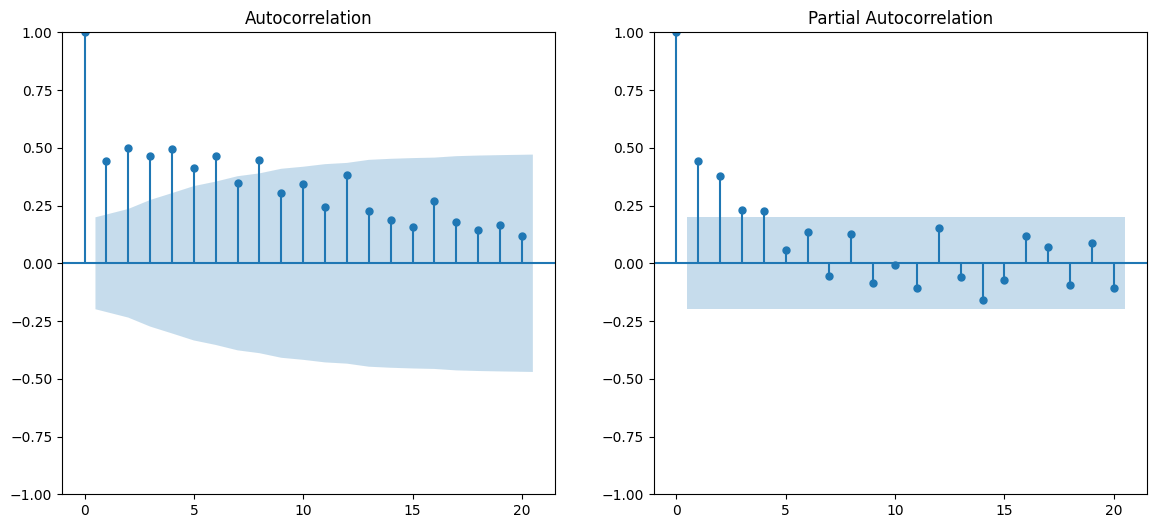

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

plot_acf(serie_brazil, ax=axes[0])
plot_pacf(serie_brazil, ax=axes[1])
plt.show()

#### Testes ADF e KPSS nas series

### Metodos para fazer os testes adf e kpss

In [35]:
from statsmodels.tsa.stattools import adfuller, kpss
def teste_adf(serie, nome):
    resultado = adfuller(serie, autolag='AIC')
    p_valor = resultado[1]
    conclusao = 'ESTACIONÁRIA' if p_valor < 0.05 else 'NÃO ESTACIONÁRIA'
    
    print(f'\n=== Teste ADF — {nome} ===')
    print(f'  Estatística ADF: {resultado[0]:.4f}')
    print(f'  p-value:         {p_valor:.6f}')
    print(f'  Lags usados:     {resultado[2]}')
    print(f'  Observações:     {resultado[3]}')
    for key, val in resultado[4].items():
        print(f'  Valor crítico {key}: {val:.4f}')
    print(f'  → Conclusão ADF: {conclusao}')
    return p_valor

def teste_kpss(serie, nome):
    resultado = kpss(serie, regression='c', nlags='auto')
    p_valor = resultado[1]
    conclusao = 'ESTACIONÁRIA' if p_valor >= 0.05 else 'NÃO ESTACIONÁRIA'
    
    print(f'\n=== Teste KPSS — {nome} ===')
    print(f'  Estatística KPSS: {resultado[0]:.4f}')
    print(f'  p-value:          {p_valor:.4f}')
    print(f'  Lags usados:      {resultado[2]}')
    for key, val in resultado[3].items():
        print(f'  Valor crítico {key}: {val:.4f}')
    print(f'  → Conclusão KPSS: {conclusao}')
    return p_valor

def analise_estacionariedade(serie, nome):
    p_adf = teste_adf(serie, nome)
    p_kpss = teste_kpss(serie, nome)
    
    print(f'\n--- Conclusão combinada para "{nome}" ---')
    if p_adf < 0.05 and p_kpss >= 0.05:
        print('  ✅ Ambos os testes concordam: ESTACIONÁRIA')
    elif p_adf >= 0.05 and p_kpss < 0.05:
        print('  ❌ Ambos os testes concordam: NÃO ESTACIONÁRIA')
    elif p_adf < 0.05 and p_kpss < 0.05:
        print('  ⚠️  Testes divergem: estacionária com tendência (diferenciação pode ajudar)')
    else:
        print('  ⚠️  Testes divergem: inconclusivo')
    print('=' * 50)

In [37]:
analise_estacionariedade(serie_property_sales, 'Valor das Casas')


=== Teste ADF — Valor das Casas ===
  Estatística ADF: -0.6602
  p-value:         0.856788
  Lags usados:     13
  Observações:     136
  Valor crítico 1%: -3.4794
  Valor crítico 5%: -2.8830
  Valor crítico 10%: -2.5782
  → Conclusão ADF: NÃO ESTACIONÁRIA

=== Teste KPSS — Valor das Casas ===
  Estatística KPSS: 1.5950
  p-value:          0.0100
  Lags usados:      8
  Valor crítico 10%: 0.3470
  Valor crítico 5%: 0.4630
  Valor crítico 2.5%: 0.5740
  Valor crítico 1%: 0.7390
  → Conclusão KPSS: NÃO ESTACIONÁRIA

--- Conclusão combinada para "Valor das Casas" ---
  ❌ Ambos os testes concordam: NÃO ESTACIONÁRIA


C:\Users\miguelaraujo-ieg\AppData\Local\Temp\ipykernel_5008\1266299260.py:18: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  resultado = kpss(serie, regression='c', nlags='auto')


In [38]:
analise_estacionariedade(serie_electric_power, 'Consumo de Energia')


=== Teste ADF — Consumo de Energia ===
  Estatística ADF: -4.8973
  p-value:         0.000035
  Lags usados:     9
  Observações:     38
  Valor crítico 1%: -3.6155
  Valor crítico 5%: -2.9413
  Valor crítico 10%: -2.6092
  → Conclusão ADF: ESTACIONÁRIA

=== Teste KPSS — Consumo de Energia ===
  Estatística KPSS: 0.1012
  p-value:          0.1000
  Lags usados:      3
  Valor crítico 10%: 0.3470
  Valor crítico 5%: 0.4630
  Valor crítico 2.5%: 0.5740
  Valor crítico 1%: 0.7390
  → Conclusão KPSS: ESTACIONÁRIA

--- Conclusão combinada para "Consumo de Energia" ---
  ✅ Ambos os testes concordam: ESTACIONÁRIA


C:\Users\miguelaraujo-ieg\AppData\Local\Temp\ipykernel_5008\1266299260.py:18: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  resultado = kpss(serie, regression='c', nlags='auto')


In [39]:
analise_estacionariedade(serie_amazon,  'Amazon')


=== Teste ADF — Amazon ===
  Estatística ADF: -5.8942
  p-value:         0.000000
  Lags usados:     0
  Observações:     23
  Valor crítico 1%: -3.7529
  Valor crítico 5%: -2.9985
  Valor crítico 10%: -2.6390
  → Conclusão ADF: ESTACIONÁRIA

=== Teste KPSS — Amazon ===
  Estatística KPSS: 0.0958
  p-value:          0.1000
  Lags usados:      5
  Valor crítico 10%: 0.3470
  Valor crítico 5%: 0.4630
  Valor crítico 2.5%: 0.5740
  Valor crítico 1%: 0.7390
  → Conclusão KPSS: ESTACIONÁRIA

--- Conclusão combinada para "Amazon" ---
  ✅ Ambos os testes concordam: ESTACIONÁRIA


C:\Users\miguelaraujo-ieg\AppData\Local\Temp\ipykernel_5008\1266299260.py:18: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  resultado = kpss(serie, regression='c', nlags='auto')


In [40]:
analise_estacionariedade(serie_brazil, 'Vitórias do Brasil')


=== Teste ADF — Vitórias do Brasil ===
  Estatística ADF: -2.0557
  p-value:         0.262685
  Lags usados:     3
  Observações:     93
  Valor crítico 1%: -3.5027
  Valor crítico 5%: -2.8932
  Valor crítico 10%: -2.5836
  → Conclusão ADF: NÃO ESTACIONÁRIA

=== Teste KPSS — Vitórias do Brasil ===
  Estatística KPSS: 1.3068
  p-value:          0.0100
  Lags usados:      5
  Valor crítico 10%: 0.3470
  Valor crítico 5%: 0.4630
  Valor crítico 2.5%: 0.5740
  Valor crítico 1%: 0.7390
  → Conclusão KPSS: NÃO ESTACIONÁRIA

--- Conclusão combinada para "Vitórias do Brasil" ---
  ❌ Ambos os testes concordam: NÃO ESTACIONÁRIA


C:\Users\miguelaraujo-ieg\AppData\Local\Temp\ipykernel_5008\1266299260.py:18: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  resultado = kpss(serie, regression='c', nlags='auto')


### Fazendo Modelo nas séries estacionarias - Amazon, Consumo de energia

#### alguns metodos para ajudar no processo do modelo

In [85]:
from statsmodels.tsa.ar_model import AutoReg
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

def train_test_split_ts(serie):
    train = serie[:-1]
    test = serie[-1:]
    return train, test

def train_model(train, lag):
    model = AutoReg(train, lags=lag).fit()
    return model

def evaluate(model, train, test):
    preds = model.predict(start=len(train), end=len(train)+len(test)-1)
    
    mae = mean_absolute_error(test, preds)
    rmse = np.sqrt(mean_squared_error(test, preds))
    
    print(f"MAE: {mae}")
    print(f"RMSE: {rmse}")

def find_best_lag(train, test, max_lag=50):
    best_lag = None
    best_error = float('inf')
    
    for lag in range(1, max_lag + 1):
        try:
            model = AutoReg(train, lags=lag).fit()
            preds = model.predict(start=len(train), end=len(train)+len(test)-1)
            
            error = mean_squared_error(test, preds)
            
            if error < best_error:
                best_error = error
                best_lag = lag
                
        except:
            continue
    
    print(f"Melhor lag: {best_lag}")
    return best_lag

def plot_forecast(train, test, preds, nome):
    fig, ax = plt.subplots(figsize=(16, 6))

    ax.plot(train.index, train,
            label='train',
            color='#4C72B0',
            linewidth=2)
    
    ax.plot(test.index, preds,
            label='Previsão',
            color='#C44E52',
            linewidth=2.5,
            linestyle='--',
            marker='o',
            markersize=6)

    ax.scatter(test.index, preds,
                color='#C44E52',
                s=60,
                zorder=3)

    ax.axvline(x=test.index[0],
                color='gray',
                linestyle=':',
                linewidth=1.5,
                alpha=0.7)

    ax.set_title(f'Previsão — {nome}', fontsize=15, fontweight='bold')

    ax.set_xlabel('Tempo', fontsize=11)
    ax.set_ylabel('Valor', fontsize=11)

##### Pipeline para o modelo autoreg

In [86]:
def run_pipeline(serie):    
    train, test = train_test_split_ts(serie)
    
    best_lag = find_best_lag(train, test)
    
    model = train_model(train, best_lag)
    
    preds = evaluate(model, train, test)
    
    plot_forecast(train, test, model.predict(start=len(train), end=len(train)+len(test)-1), nome=serie.name)
    
    return test, preds


#### Modelo para serie da amazon

c:\Users\miguelaraujo-ieg\OneDrive - Instituto J&F\3°ANO\Séries Temporais\series-temporais\.venv\Lib\site-packages\statsmodels\regression\linear_model.py:1717: RuntimeWarning: divide by zero encountered in scalar divide
  return np.dot(wresid, wresid) / self.df_resid


Melhor lag: 10
MAE: 0.07851073641793738
RMSE: 0.07851073641793738


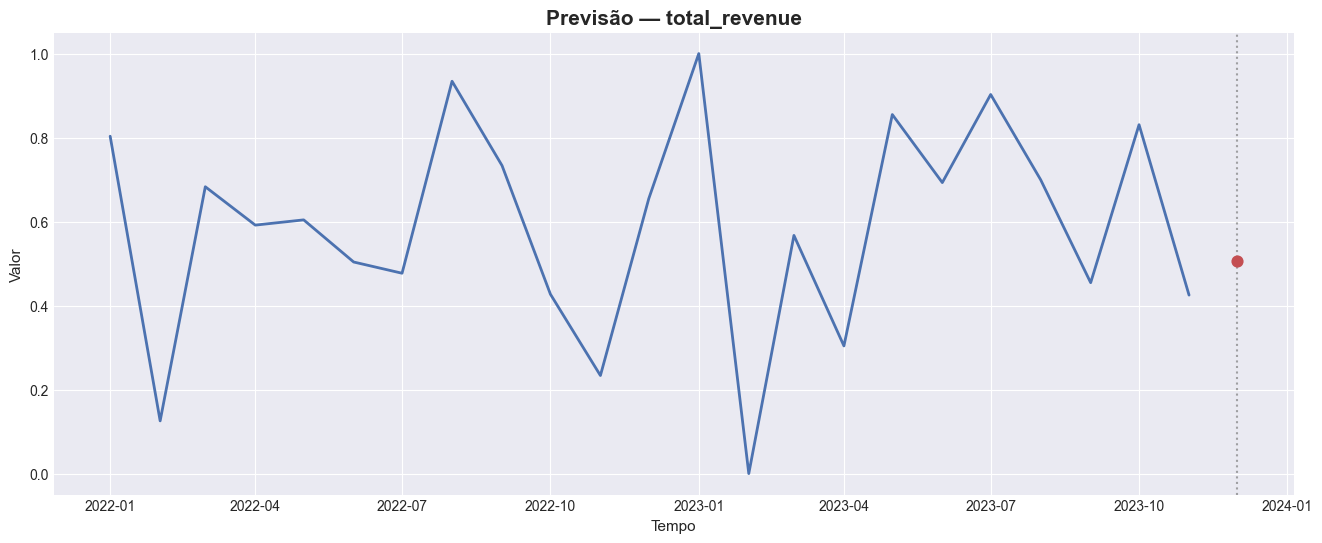

In [90]:
test,preds = run_pipeline(serie_amazon)

#### Modelo para a serie de consumo de eletricidade

Melhor lag: 6
MAE: 0.003323047825610881
RMSE: 0.003323047825610881


c:\Users\miguelaraujo-ieg\OneDrive - Instituto J&F\3°ANO\Séries Temporais\series-temporais\.venv\Lib\site-packages\statsmodels\regression\linear_model.py:1717: RuntimeWarning: divide by zero encountered in scalar divide
  return np.dot(wresid, wresid) / self.df_resid


(datetime
 2010-11-01    0.566447
 Freq: MS, Name: Global_active_power, dtype: float64,
 None)

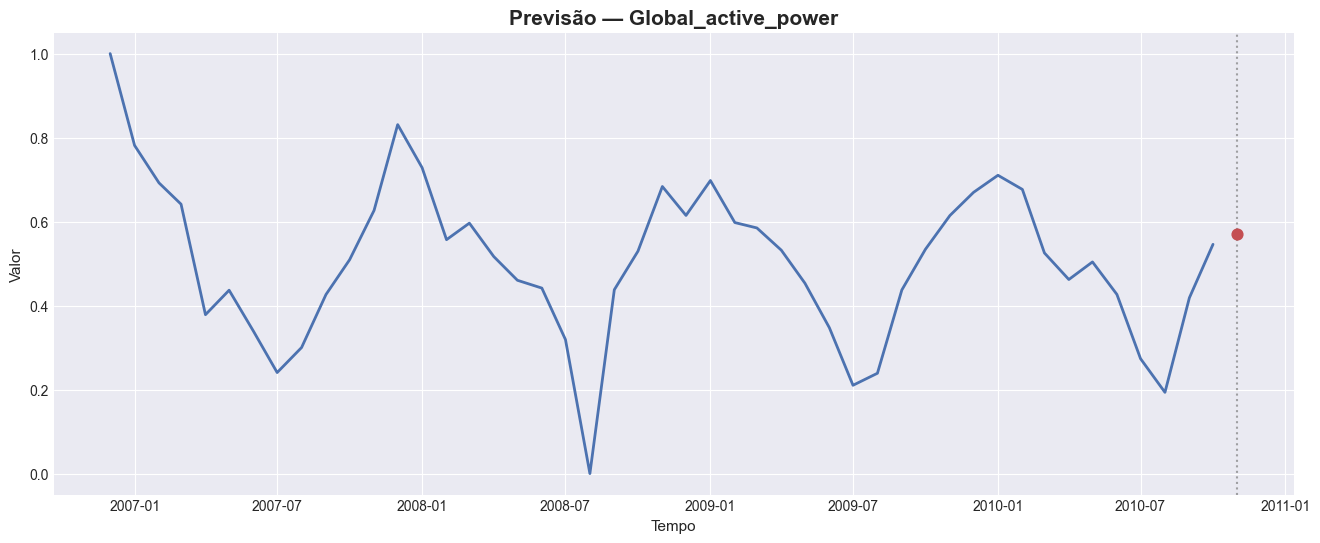

In [92]:
run_pipeline(serie_electric_power)

#### 